### Fine-tune any Ultralytics YOLOv8 model to prepare it as a face detector using WIDER FACE training set by splitting it into training set and validation set. Compare fine-tuned YOLOv8 based face detector with face detector available in the following GitHub directory using the validation set of WIDER FACE dataset. https://github.com/Yusepp/YOLOv8-Face



In [ ]:
!pip install -q kaggle
!pip install -q ultralytics


from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d mksaad/wider-face-a-face-detection-benchmark

!unzip wider-face-a-face-detection-benchmark.zip -d WIDERFACE


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.3 MB/s eta 0:00:00


Streaming output truncated to the last 5000 lines.
  inflating: WIDERFACE/wider_train/WIDER_train/images/55--Sports_Coach_Trainer/55_Sports_Coach_Trainer_sportcoaching_55_16.jpg  
  inflating: WIDERFACE/wider_train/WIDER_train/images/55--Sports_Coach_Trainer/55_Sports_Coach_Trainer_sportcoaching_55_177.jpg  
  inflating: WIDERFACE/wider_train/WIDER_train/images/55--Sports_Coach_Trainer/55_Sports_Coach_Trainer_sportcoaching_55_180.jpg  
  inflating: WIDERFACE/wider_train/WIDER_train/images/55--Sports_Coach_Trainer/55_Sports_Coach_Trainer_sportcoaching_55_185.jpg  
  inflating: WIDERFACE/wider_train/WIDER_train/images/55--Sports_Coach_Trainer/55_Sports_Coach_Trainer_sportcoaching_55_19.jpg  
  inflating: WIDERFACE/wider_train/WIDER_train/images/55--Sports_Coach_Trainer/55_Sports_Coach_Trainer_sportcoaching_55_2.jpg  
  inflating: WIDERFACE/wider_train/WIDER_train/images/55--Sports_Coach_Trainer/55_Sports_Coach_Trainer_sportcoaching_55_214.jpg  
  inflating: WIDERFACE/wider_train/WIDER_tr

#### Convert Annotations to YOLO Format


In [ ]:
import os
import cv2

def convert_widerface_to_yolo(img_dir, label_file, out_img_dir, out_label_dir):
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_label_dir, exist_ok=True)

    with open(label_file, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        filename = lines[i].strip()
        num_faces = int(lines[i + 1].strip())
        boxes = [list(map(int, lines[i + 2 + j].strip().split()[:4])) for j in range(num_faces)]
        i += 2 + num_faces

        img_path = os.path.join(img_dir, filename)
        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]


        out_img_path = os.path.join(out_img_dir, filename)
        os.makedirs(os.path.dirname(out_img_path), exist_ok=True)
        cv2.imwrite(out_img_path, img)

        label_path = os.path.join(out_label_dir, filename.replace('.jpg', '.txt'))
        os.makedirs(os.path.dirname(label_path), exist_ok=True)
        with open(label_path, 'w') as f:
            for box in boxes:
                x, y, bw, bh = box
                cx = (x + bw / 2) / w
                cy = (y + bh / 2) / h
                bw /= w
                bh /= h
                f.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")


#### Run Conversion

In [ ]:
convert_widerface_to_yolo(
    img_dir='WIDERFACE/WIDER_train/WIDER_train/images',
    label_file='WIDERFACE/wider_face_split/wider_face_split/wider_face_train_bbx_gt.txt',
    out_img_dir='dataset/images/train',
    out_label_dir='dataset/labels/train'
)

convert_widerface_to_yolo(
    img_dir='WIDERFACE/WIDER_val/WIDER_val/images',
    label_file='WIDERFACE/wider_face_split/wider_face_split/wider_face_val_bbx_gt.txt',
    out_img_dir='dataset/images/val',
    out_label_dir='dataset/labels/val'
)


#### face.yaml

In [ ]:
with open('face.yaml', 'w') as f:
    f.write("""
path: dataset
train: images/train
val: images/val

nc: 1
names: ['face']
""")


#### Train YOLOv8 on WIDER FACE


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='face.yaml',
    epochs=5,
    imgsz=640,
    batch=8,
    name='yolov8-face'
)


Ultralytics 8.3.162 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=face.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8-face3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile

train: Scanning /content/dataset/labels/train/0--Parade.cache... 12880 images, 0 backgrounds, 2 corrupt: 100%|██████████| 12880/12880 [00:00<?, ?it/s]

train: /content/dataset/images/train/2--Demonstration/2_Demonstration_Protesters_2_231.jpg: 1 duplicate labels removed
train: /content/dataset/images/train/37--Soccer/37_Soccer_Soccer_37_851.jpg: 1 duplicate labels removed
train: /content/dataset/images/train/54--Rescue/54_Rescue_rescuepeople_54_29.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0127]
train: /content/dataset/images/train/7--Cheering/7_Cheering_Cheering_7_17.jpg: ignoring corrupt image/label: negative label values [  -0.005371   -0.010742]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 56.4±20.3 MB/s, size: 219.1 KB)


val: Scanning /content/dataset/labels/val/0--Parade.cache... 3226 images, 0 backgrounds, 1 corrupt: 100%|██████████| 3226/3226 [00:00<?, ?it/s]

...

        5/5      9.18G      1.532     0.8449      1.026         32        640: 100%|██████████| 1610/1610 [04:57<00:00,  5.41it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 202/202 [00:34<00:00,  5.82it/s]


                   all       3225      39675      0.798      0.519      0.593      0.311

5 epochs completed in 0.474 hours.
Optimizer stripped from runs/detect/yolov8-face3/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/yolov8-face3/weights/best.pt, 6.2MB

Validating runs/detect/yolov8-face3/weights/best.pt...
Ultralytics 8.3.162 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 202/202 [00:35<00:00,  5.72it/s]


                   all       3225      39675      0.796      0.519      0.593      0.311
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to runs/detect/yolov8-face3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b8000bf1810>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

#### Inference


image 1/1 /content/WIDERFACE/WIDER_val/WIDER_val/images/11--Meeting/11_Meeting_Meeting_11_Meeting_Meeting_11_102.jpg: 448x640 6 faces, 35.8ms
Speed: 3.2ms preprocess, 35.8ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)


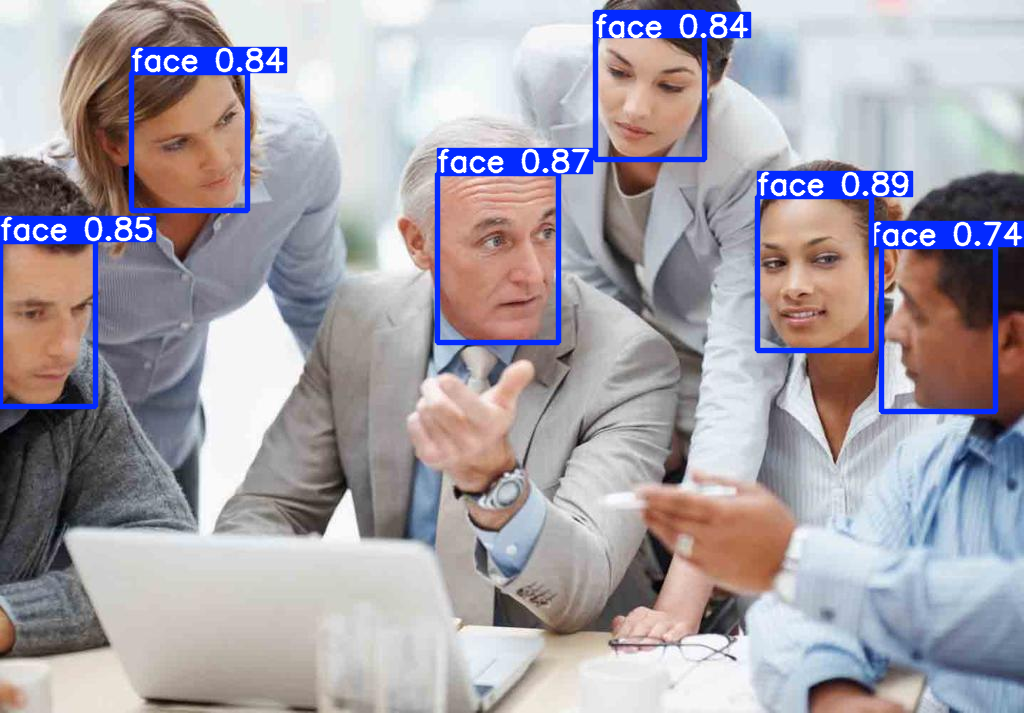

In [ ]:
results = model('/content/WIDERFACE/WIDER_val/WIDER_val/images/11--Meeting/11_Meeting_Meeting_11_Meeting_Meeting_11_102.jpg')
results[0].show()


In [ ]:
model = YOLO('runs/detect/yolov8-face/weights/best.pt')
metrics = model.val(data='face.yaml')
print(metrics.box.map)

Ultralytics 8.3.162 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3527.4±1402.1 MB/s, size: 311.0 KB)


val: Scanning /content/dataset/labels/val/0--Parade.cache... 3226 images, 0 backgrounds, 1 corrupt: 100%|██████████| 3226/3226 [00:00<?, ?it/s]

val: /content/dataset/images/val/21--Festival/21_Festival_Festival_21_604.jpg: 1 duplicate labels removed
val: /content/dataset/images/val/39--Ice_Skating/39_Ice_Skating_iceskiing_39_583.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [      1.001]



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 202/202 [00:36<00:00,  5.48it/s]


                   all       3225      39675      0.718      0.398      0.436      0.212
Speed: 0.2ms preprocess, 3.2ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/val
0.21202325259072427


#### Measured inference speed (FPS) on 100 validation images

In [ ]:
import time
import glob

# Load your model
model = YOLO("runs/detect/yolov8-face/weights/best.pt")

# Load list of image paths (adjust path if needed)
imgs = sorted(glob.glob("/content/WIDERFACE/WIDER_val/WIDER_val/images/*/*.jpg"))[:100]  # first 100 images

# Start timing
t0 = time.time()

# Run inference
_ = model.predict(source=imgs, imgsz=640, batch=8, verbose=False)

# Calculate and print FPS
fps = len(imgs) / (time.time() - t0)
print(f"{fps:.2f} FPS")


42.09 FPS


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving yolov8n_100e.pt to yolov8n_100e.pt


In [ ]:
from ultralytics import YOLO

# Your model
model_yours = YOLO("runs/detect/yolov8-face/weights/best.pt")
metrics_yours = model_yours.val(data="face.yaml")
print("Your Model mAP50-95:", metrics_yours.box.map)

# Yusepp model
model_yusepp = YOLO("yolov8n_100e.pt")
metrics_yusepp = model_yusepp.val(data="face.yaml")
print("Yusepp Model mAP50-95:", metrics_yusepp.box.map)


Ultralytics 8.3.162 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3106.9±963.1 MB/s, size: 195.4 KB)


val: Scanning /content/dataset/labels/val/0--Parade.cache... 3226 images, 0 backgrounds, 1 corrupt: 100%|██████████| 3226/3226 [00:00<?, ?it/s]

val: /content/dataset/images/val/21--Festival/21_Festival_Festival_21_604.jpg: 1 duplicate labels removed
val: /content/dataset/images/val/39--Ice_Skating/39_Ice_Skating_iceskiing_39_583.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [      1.001]



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 202/202 [00:35<00:00,  5.61it/s]


                   all       3225      39675      0.718      0.398      0.436      0.212
Speed: 0.2ms preprocess, 2.8ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/val2
👉 Your Model mAP50-95: 0.21202325259072427
Ultralytics 8.3.162 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2667.5±800.2 MB/s, size: 195.6 KB)


val: Scanning /content/dataset/labels/val/0--Parade.cache... 3226 images, 0 backgrounds, 1 corrupt: 100%|██████████| 3226/3226 [00:00<?, ?it/s]

val: /content/dataset/images/val/21--Festival/21_Festival_Festival_21_604.jpg: 1 duplicate labels removed
val: /content/dataset/images/val/39--Ice_Skating/39_Ice_Skating_iceskiing_39_583.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [      1.001]



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 202/202 [00:36<00:00,  5.58it/s]


                   all       3225      39675      0.828       0.56       0.63      0.336
Speed: 0.3ms preprocess, 2.8ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/val3
👉 Yusepp Model mAP50-95: 0.33554246870962456


In [ ]:
imgs = sorted(glob.glob("/content/WIDERFACE/WIDER_val/WIDER_val/images/*/*.jpg"))[:100]

def measure_fps(model, imgs):
    t0 = time.time()
    _ = model.predict(source=imgs, imgsz=640, batch=8, verbose=False)
    fps = len(imgs) / (time.time() - t0)
    return fps

fps_yours = measure_fps(model_yours, imgs)
fps_yusepp = measure_fps(model_yusepp, imgs)

print(f" Your Model FPS: {fps_yours:.2f}")
print(f" Yusepp Model FPS: {fps_yusepp:.2f}")


👉 Your Model FPS: 35.82
👉 Yusepp Model FPS: 52.20


### Build a face detector having the architecture of YOLOv1, train it using WIDERFACE WIDER FACE training set by splitting it into training set and validation set.

#### YOLOv1 Model Implementation in PyTorch


In [ ]:
# yolov1.py
import torch.nn as nn
import torch

class YOLOv1(nn.Module):
    def __init__(self, S=7, B=2, C=1):
        super(YOLOv1, self).__init__()
        self.S, self.B, self.C = S, B, C

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 192, 3, 1, 1), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(192, 128, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(128, 256, 3, 1, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(256, 256, 1), nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, 3, 1, 1), nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(4096, S * S * (B * 5 + C))
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x.view(-1, self.S, self.S, self.B * 5 + self.C)


In [ ]:
class WiderFaceYOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        # Store image paths and matching label paths
        # Load + resize image
        # Parse label file into YOLOv1 tensor (S x S x 11)



SyntaxError: invalid syntax (ipython-input-19-2746829583.py, line 8)